Category: inside_bus


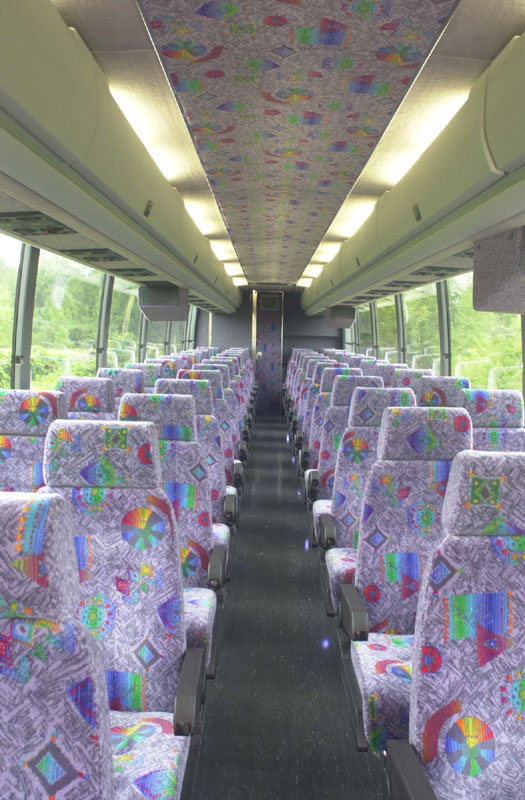

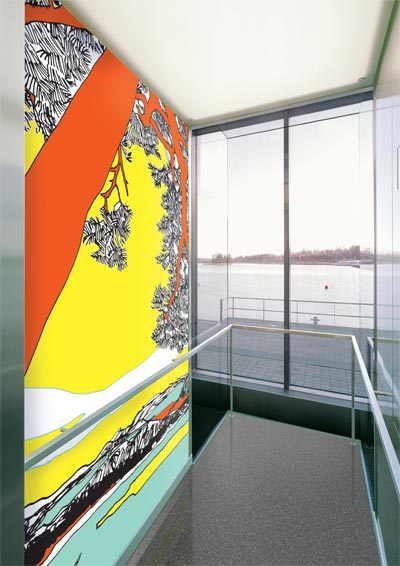



Category: elevator


Category: movietheater


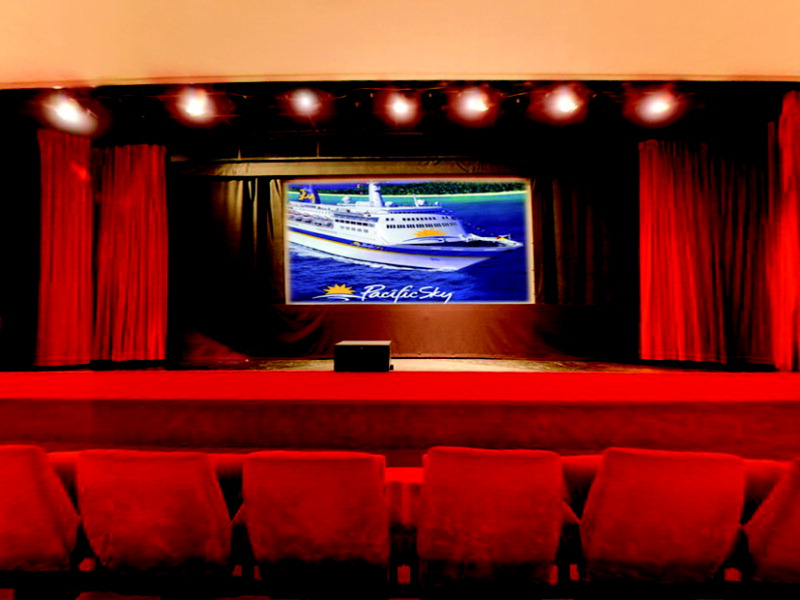



Category: laboratorywet


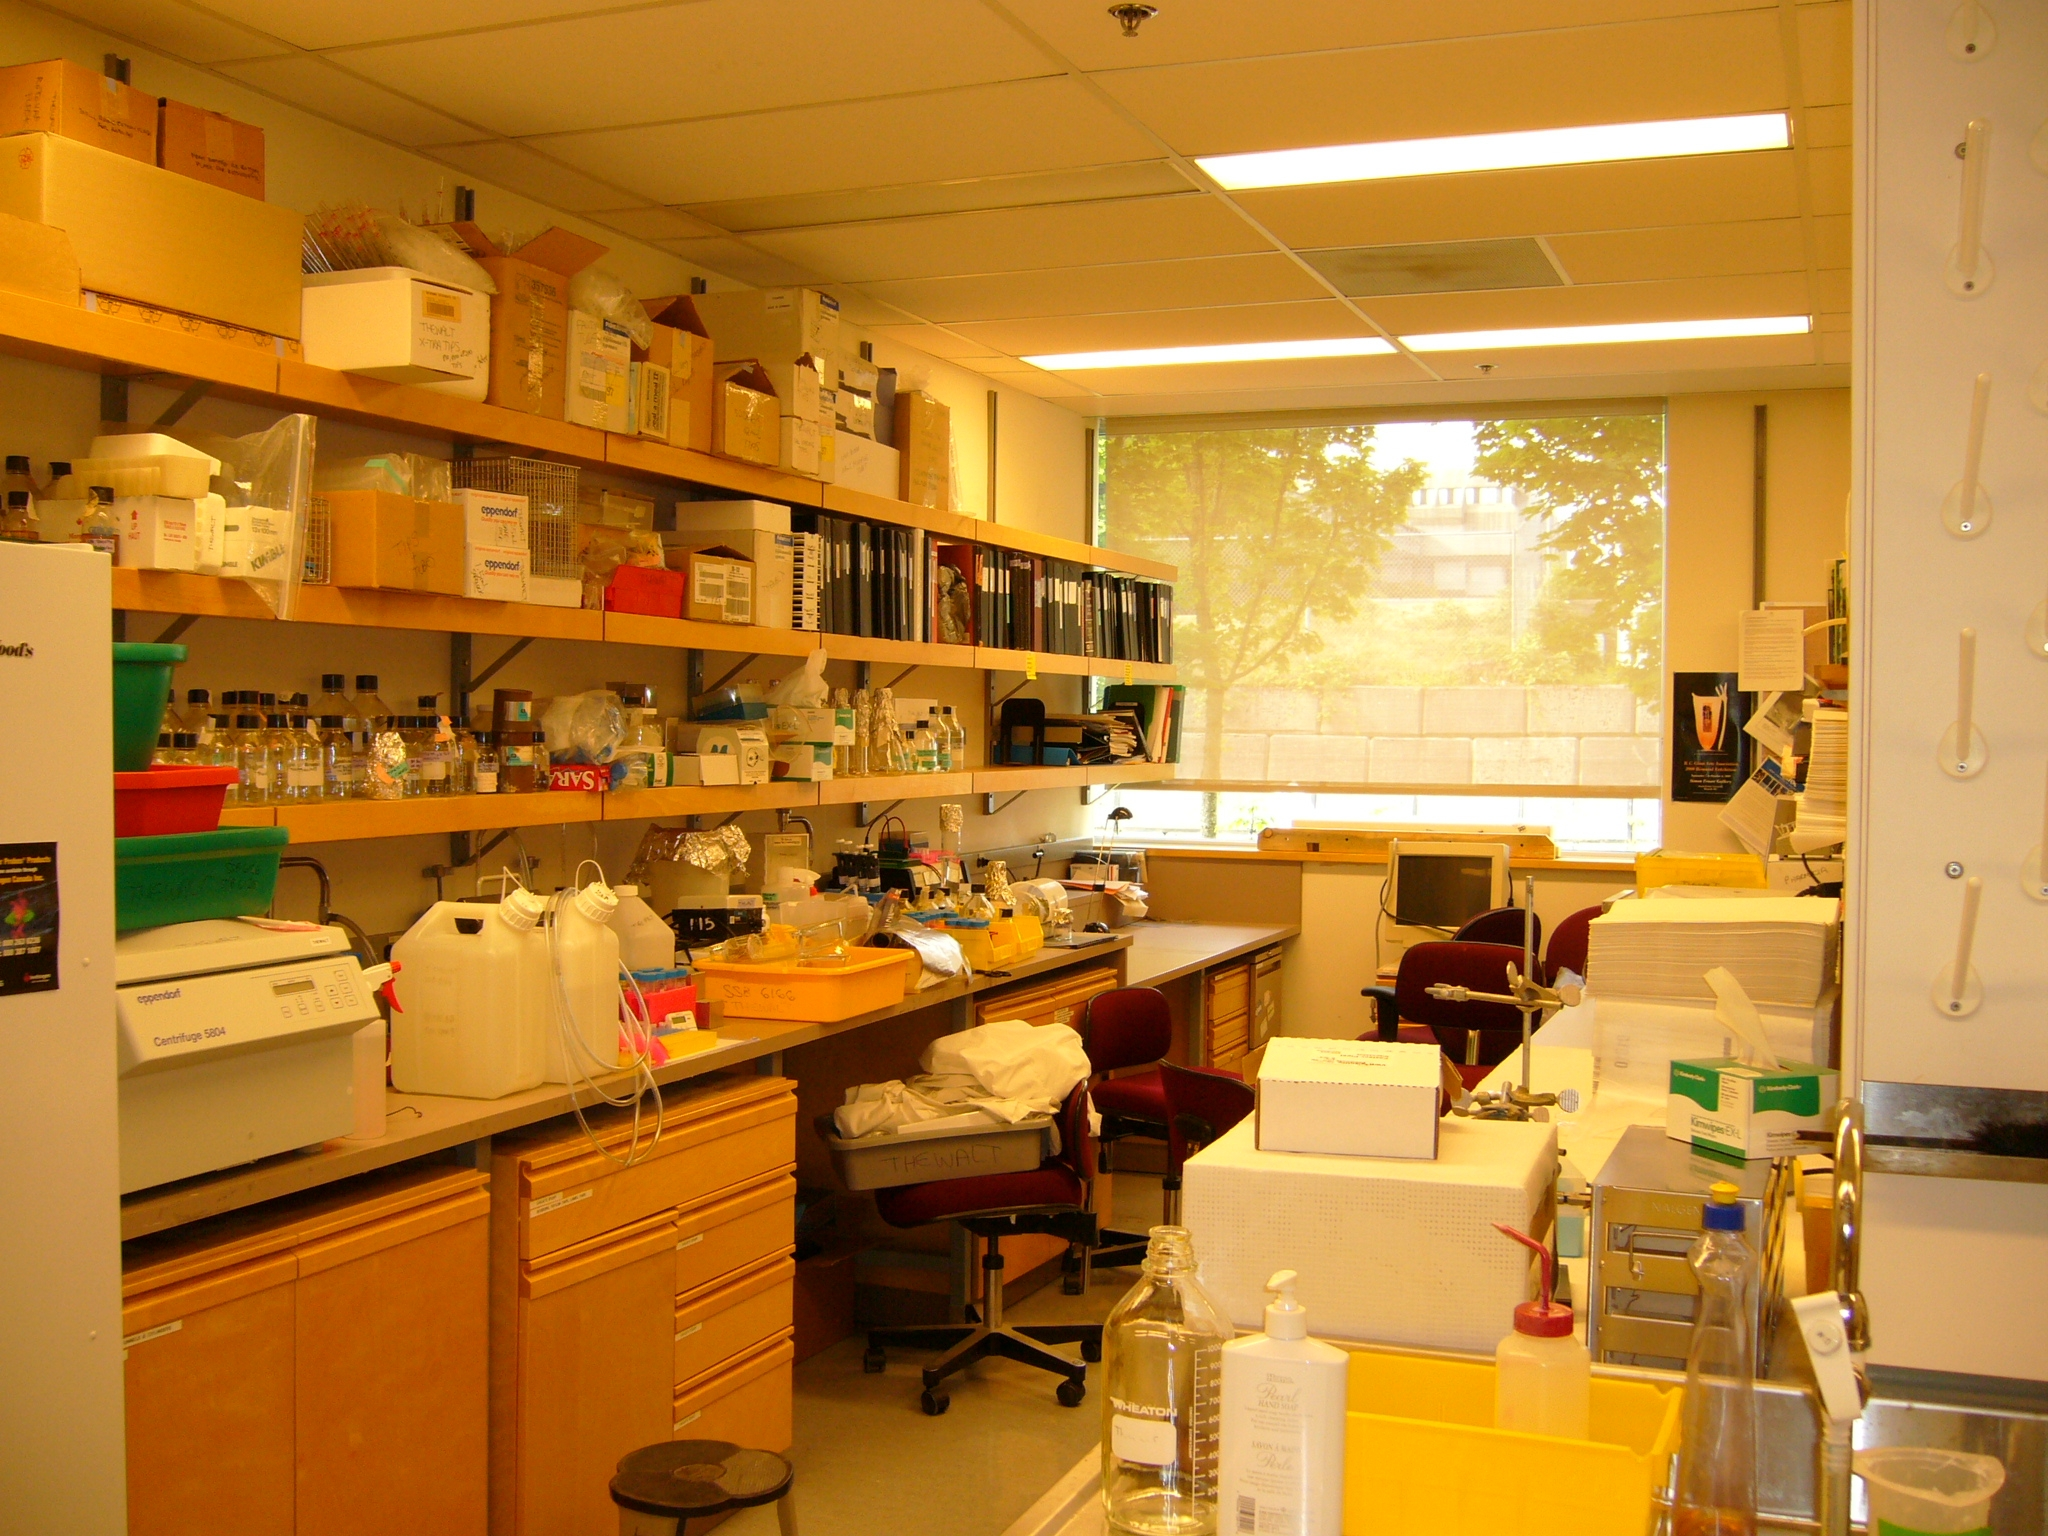



Category: bowling


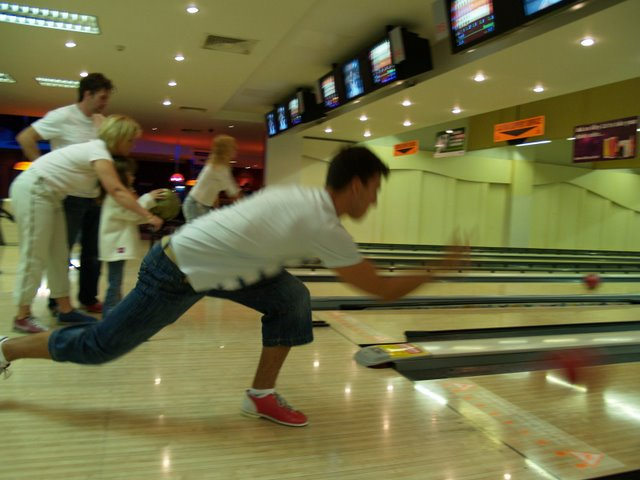

In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
from IPython.display import Image, display
import os
import random

# Specify the directory path
directory_path = 'data_small/indoorCVPR_09/Images/'

def load_random_image_from_category(category_path):
    # Get the list of image files in the category
    image_files = [file for file in os.listdir(category_path) if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
    
    # Randomly select one image from the category
    random_image = random.choice(image_files)
    
    return random_image

# Get the list of categories in the directory
categories = os.listdir(directory_path)

# Specify the number of classes to consider
num_classes = 5

# Randomly select one image from each of the five classes
selected_categories = random.sample(categories, num_classes)

# Display one random image from each of the five classes
for category_name in selected_categories:
    category_path = os.path.join(directory_path, category_name)

    # Check if the entry is a directory
    if os.path.isdir(category_path):
        random_image_name = load_random_image_from_category(category_path)
        random_image_path = os.path.join(category_path, random_image_name)
        
        print(f"Category: {category_name}")
        display(Image(filename=random_image_path))
        print("\n" + "="*30 + "\n")  # Separating images with a line

In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms

transformations = transforms.Compose([transforms.Resize((256, 256)), transforms.ToTensor()])

dataset = ImageFolder(directory_path, transform = transformations)

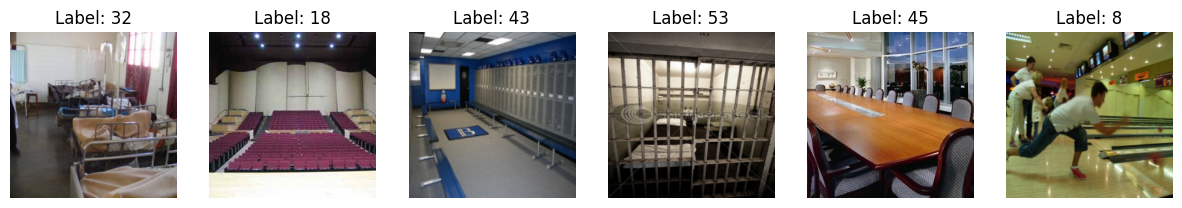

In [3]:
# --- [CELL 2]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
import matplotlib.pyplot as plt # for reporducing and fixing purposes
import torch

def show_images(dataset, num_images=6):

    # Get random indices from the dataset
    random_indices = torch.randperm(len(dataset))[:num_images]

    # Create a subplot with the specified number of rows and columns
    rows = 1
    cols = num_images
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3))

    for i, idx in enumerate(random_indices):
        # Get the image and label from the dataset
        image, label = dataset[idx]

        # Convert the PyTorch tensor to a NumPy array for visualization
        image_np = image.permute(1, 2, 0).numpy()

        # Display the image
        axes[i].imshow(image_np)
        axes[i].set_title(f"Label: {label}")

        # Remove x and y axis ticks
        axes[i].axis("off")

    plt.show()

# Call the helper function to display images from the transformed dataset
transformed = dataset # fix for reporducing and fixing purposes, undefined variable
show_images(transformed)

In [4]:
# --- [CELL 3]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 4}
from torch.utils.data import random_split

class_mapping = transformed.class_to_idx
num_classes = len(class_mapping)

# Split the indices
train_size = 420 #12000
val_size = 150 #3000
test_size = 100# 620

train_indices, val_indices, test_indices = random_split(
    range(len(transformed)),
    [train_size, val_size, test_size]
)

# Create new datasets based on the split indices
train_ds = torch.utils.data.Subset(transformed, train_indices)
val_ds = torch.utils.data.Subset(transformed, val_indices)
test_ds = torch.utils.data.Subset(transformed, test_indices)

# Print lengths of datasets
print(len(train_ds), len(val_ds), len(test_ds))

420 150 100


In [5]:
# --- [CELL 4]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 5}
from torch.utils.data import DataLoader

batch_size = 25
# for reporducing and fixing purposes, change setting to cpu
# train_dl = DataLoader(train_ds, batch_size, shuffle = True, num_workers = 2, pin_memory = True)
# val_dl = DataLoader(val_ds, batch_size*2, num_workers = 4, pin_memory = True)
train_dl = DataLoader(train_ds, batch_size, shuffle = True, num_workers = 0, pin_memory = False)
val_dl = DataLoader(val_ds, batch_size*2, num_workers = 0, pin_memory = False)

In [6]:
# --- [CELL 5]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 6}
import torch.nn as nn
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

class ImageClassificationBase(nn.Module):
    def training_step(self, batch):
        images, labels = batch
        out = self(images)                  # Generate predictions
        loss = F.cross_entropy(out, labels) # Calculate loss
        return loss

    def validation_step(self, batch):
        images, labels = batch
        out = self(images)                    # Generate predictions
        loss = F.cross_entropy(out, labels)   # Calculate loss
        acc = accuracy(out, labels)           # Calculate accuracy
        return {'val_loss': loss.detach(), 'val_acc': acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print("Epoch {}: train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch+1, result['train_loss'], result['val_loss'], result['val_acc']))

In [7]:
# --- [CELL 6]: ---
# cell_state: unchanged
# execution_status: {'status': 'error', 'done': True, 'execution_count': 7}
import torchvision.models as models
class ResNet(ImageClassificationBase):
    def __init__(self):
        super().__init__()
        # Use a pretrained model
        self.network = models.resnet18(pretrained=True)
        # Replace last layer
        num_ftrs = self.network.fc.in_features
        self.network.fc = nn.Linear(num_ftrs, len(transformed.classes))

    def forward(self, xb):
        return torch.sigmoid(self.network(xb))

model = ResNet()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /tmp/xdg-cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 87.8MB/s]


In [8]:
# --- [CELL 7]: ---
# cell_state: edited
# execution_status: {'status': 'not run'}
# === BEFORE (original) ===
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import torch.nn.functional as F
# from torch.utils.data import DataLoader
# 
# # Assuming you have a DataLoader for training and validation (train_dl, val_dl)
# # Make sure to set num_classes as appropriate
# 
# # Initialize the modified ResNet model
# resnet_model = models.resnet18(pretrained=True)
# 
# # Define your loss function and optimizer
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.SGD(resnet_model.parameters(), lr=0.001, momentum=0.9) # fix for crash isolation purposes # resnet_model instead of model
# 
# # Training loop
# num_epochs = 1  # Adjust as needed # 10
# 
# for epoch in range(num_epochs):
#     resnet_model.train()  # fix for crash isolation purposes # resnet_model instead of model
#     for inputs, labels in train_dl:
#         optimizer.zero_grad()
#         outputs = resnet_model(inputs)  # fix for crash isolation purposes # resnet_model instead of model
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()
# 
#     # Validation loop
#     resnet_model.eval()  # fix for crash isolation purposes # resnet_model instead of model
#     with torch.no_grad():
#         correct = 0
#         total = 0
#         for inputs, labels in val_dl:
#             outputs = resnet_model(inputs)  # fix for crash isolation purposes # resnet_model instead of model
#             _, predicted = torch.max(outputs.data, 1)
#             total += labels.size(0)
#             correct += (predicted == labels).sum().item()
# 
#         accuracy = correct / total
#         print(f'Epoch {epoch + 1}/{num_epochs}, Validation Accuracy: {accuracy:.4f}')
# 
# # After training, you can use the evaluate function
# def evaluate(model, test_dl):
#     model.eval()
#     with torch.no_grad():
#         correct = 0
#         total = 0
#         for inputs, labels in test_dl:
#             # Ensure the batch dimension is added at the beginning
#             inputs = inputs.unsqueeze(-1)  # Assuming the channels dimension is 1 (grayscale), change to 0 for RGB
#             outputs = model(inputs)
#             
#             _, predicted = torch.max(outputs.data, 1)
#             total += labels.size(0)
#             correct += (predicted == labels).sum().item()
# 
#         accuracy = correct / total
#         print(f'Test Accuracy: {accuracy:.4f}')
# 
# 
# # Usage
# evaluate(resnet_model,val_dl) # fix for crash isolation purposes # val_dl instead of val_ds

# === AFTER (edited) ===
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.models as models





resnet_model = models.resnet18(pretrained=True)

# Modify the final layer to match the number of classes in the dataset
num_ftrs = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_ftrs, len(transformed.classes))


criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet_model.parameters(), lr=0.001, momentum=0.9)


num_epochs = 1

for epoch in range(num_epochs):
    resnet_model.train()
    for inputs, labels in train_dl:
        optimizer.zero_grad()
        outputs = resnet_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()


    resnet_model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for inputs, labels in val_dl:
            outputs = resnet_model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        accuracy = correct / total
        print(f'Epoch {epoch + 1}/{num_epochs}, Validation Accuracy: {accuracy:.4f}')


def evaluate(model, test_dl):
    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for inputs, labels in test_dl:

            outputs = model(inputs)

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        accuracy = correct / total
        print(f'Test Accuracy: {accuracy:.4f}')



evaluate(resnet_model,val_dl)

Epoch 1/1, Validation Accuracy: 0.0067
Test Accuracy: 0.0067


In [9]:
# Behavioral test: Verify evaluate function processes correctly shaped input tensors
# This test would fail if unsqueeze(-1) was active (shape mismatch error)
# and passes if the input is used without the extra unsqueezing

# Create a mock DataLoader with correct shape tensors (batch, channels, height, width)
from torch.utils.data import DataLoader, TensorDataset

# Create synthetic test data matching ResNet18 expectations: (batch_size, 3, 224, 224)
test_inputs = torch.randn(2, 3, 224, 224)  # batch=2, channels=3, H=224, W=224
test_labels = torch.randint(0, 67, (2,))  # 2 labels in range [0, 67)
test_dataset = TensorDataset(test_inputs, test_labels)
test_dl = DataLoader(test_dataset, batch_size=2)

# Verify evaluate runs without shape error (would fail with unsqueeze)
try:
    evaluate(resnet_model, test_dl)
    test_passed = True
except RuntimeError as e:
    # If unsqueeze(-1) is still active, we'll get shape mismatch error
    if "shape" in str(e).lower() or "size" in str(e).lower():
        test_passed = False
    else:
        raise

assert test_passed, "evaluate function should process correctly-shaped inputs without error"
print("✓ Test passed: evaluate function works with proper input shapes")

Test Accuracy: 0.0000
✓ Test passed: evaluate function works with proper input shapes
